In [2]:
import pandas as pd 
import numpy as np 

import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
silhouette_score,
davies_bouldin_score,
calinski_harabasz_score
) 

import joblib

In [3]:
#Load CSV 
df = pd.read_csv("../data/Hotel_Reviews.csv")
# Check Shape 
df.shape    #(515738, 17)


(515738, 17)

In [4]:
#PHASE 3 — Understand the Dataset

df.head()  # first 5  rows 
print("======================================")
df.tail()  # last 5 rows
print("=======================================")
df.info()  # Dataset infomation 

print("=====================================")
df.describe()
print("=====================================")

df.columns


<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  str    
 10  Review_

Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='str')

In [5]:
#PHASE 4 — Data Quality & Cleaning 

df.isnull().sum()  # Missing Values Sum 

df_clean = df.copy() # we creata a copy of dataset

df_clean.duplicated().sum()  # duplicated rows  526 

df_clean = df_clean.drop_duplicates() # duplicates rows will be drop 


df_clean["Reviewer_Score"].describe()

df_clean["Average_Score"].describe()


count    515212.000000
mean          8.397767
std           0.547952
min           5.200000
25%           8.100000
50%           8.400000
75%           8.800000
max           9.800000
Name: Average_Score, dtype: float64

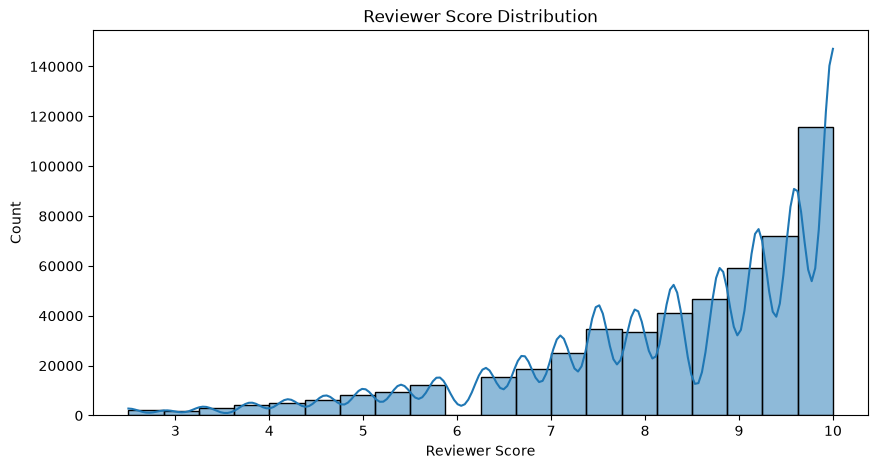

In [6]:
#PHASE 5 — Exploratory Data Analysis :- before clustering understanding the data

#Step 5.1 — Reviewer Score Distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Reviewer_Score"],
    bins=20,
    kde=True
)

plt.title("Reviewer Score Distribution")
plt.xlabel("Reviewer Score")
plt.show()

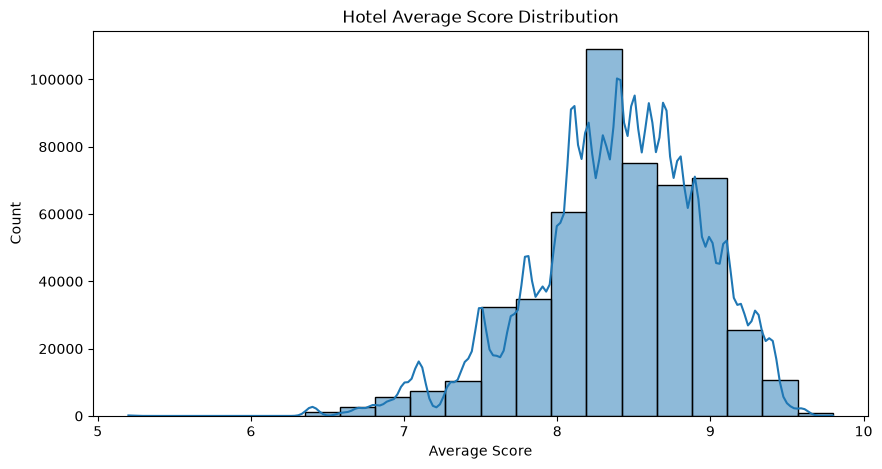

In [7]:
#step 5.2 - Hotel Average  Score 
plt.figure(figsize=(10, 5))

sns.histplot(
    df_clean["Average_Score"],
    bins=20,
    kde=True
)
plt.title("Hotel Average Score Distribution")
plt.xlabel("Average Score")
plt.show()

In [8]:
#step 5.3 - Numer of unique hotels 

df_clean["Hotel_Name"].nunique()

# This is important.

# Because now we decide:

# We should cluster hotels, not 515,738 individual reviews.

1492

In [9]:
#PHASE 6 — Aggregate Reviews into Hotels
hotel_df = df_clean.groupby("Hotel_Name").agg({
    "Average_Score": "median",
    "Reviewer_Score": "mean",
    "Total_Number_of_Reviews":"median",
    "Additional_Number_of_Scoring":"median",
    "Review_Total_Negative_Word_Counts":"mean",
    "Review_Total_Positive_Word_Counts":"mean",
    "Total_Number_of_Reviews_Reviewer_Has_Given":"mean",
    "lat":"first",
    "lng":"first"
}).reset_index()

In [10]:
# Check Result 
hotel_df.shape  # (1492, 10)

hotel_df.head()

,Hotel_Name,Average_Score,Reviewer_Score,Total_Number_of_Reviews,Additional_Number_of_Scoring,Review_Total_Negative_Word_Counts,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,lat,lng
0,11 Cadogan Gardens,8.7,8.845283,393.0,101.0,15.528302,19.974843,7.226415,51.493616,-0.159235
1,1K Hotel,7.7,7.861486,663.0,69.0,24.932432,15.601351,9.141892,48.863932,2.365874
2,25hours Hotel beim MuseumsQuartier,8.8,8.983309,4324.0,391.0,16.161103,21.911466,8.722787,48.206474,16.354630
3,41,9.6,9.711650,244.0,66.0,8.883495,25.300971,6.009709,51.498147,-0.143649
4,45 Park Lane Dorchester Collection,9.4,9.603571,68.0,27.0,6.750000,11.535714,7.214286,51.506371,-0.151536


In [11]:
# phase 7 -Feature Engineering  

#Feature 1 - Sentiment Balance
hotel_df["sentiment_balance"] = (
    hotel_df["Review_Total_Positive_Word_Counts"]
    -
    hotel_df["Review_Total_Negative_Word_Counts"]
) / (
    hotel_df["Review_Total_Positive_Word_Counts"]
    +
    hotel_df["Review_Total_Negative_Word_Counts"]
    + 1
)

In [12]:
#Feature 2 - Review Volume
hotel_df["review_volume"] = (
    hotel_df["Total_Number_of_Reviews"]
    +
    hotel_df["Additional_Number_of_Scoring"]
)

In [13]:
#Feature 3 - Log Review Volume 
hotel_df["log_review_volume"]=np.log1p(
    hotel_df["review_volume"]
)

In [14]:
#PHASE 8 — Validate Engineered Features - Before selecting feature , check them 

hotel_df[[
    "Average_Score",
    "Reviewer_Score",
    "sentiment_balance",
    "review_volume",
    "log_review_volume",
    "Total_Number_of_Reviews_Reviewer_Has_Given"
]].describe()

,Average_Score,Reviewer_Score,sentiment_balance,review_volume,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,8.467225,8.468132,0.034400,1488.309651,6.855912,7.825513
std,0.548412,0.622728,0.200036,1578.067727,0.986274,2.501348
min,5.200000,5.121538,-0.547588,50.000000,3.931826,2.571429
25%,8.100000,8.093865,-0.105759,484.500000,6.185178,6.095501
50%,8.500000,8.505886,0.025447,994.500000,6.903245,7.515020
75%,8.900000,8.930305,0.168666,1913.500000,7.557212,9.123615
max,9.800000,9.725000,0.647309,17574.000000,9.774233,46.884615


In [15]:
#Check  missing values
hotel_df.isnull().sum()

Hotel_Name                                     0
Average_Score                                  0
Reviewer_Score                                 0
Total_Number_of_Reviews                        0
Additional_Number_of_Scoring                   0
Review_Total_Negative_Word_Counts              0
Review_Total_Positive_Word_Counts              0
Total_Number_of_Reviews_Reviewer_Has_Given     0
lat                                           17
lng                                           17
sentiment_balance                              0
review_volume                                  0
log_review_volume                              0
dtype: int64

In [16]:
#check infinite values - ideally all should be zero 
np.isinf(
    hotel_df.select_dtypes(include=np.number)
).sum()

Average_Score                                 0
Reviewer_Score                                0
Total_Number_of_Reviews                       0
Additional_Number_of_Scoring                  0
Review_Total_Negative_Word_Counts             0
Review_Total_Positive_Word_Counts             0
Total_Number_of_Reviews_Reviewer_Has_Given    0
lat                                           0
lng                                           0
sentiment_balance                             0
review_volume                                 0
log_review_volume                             0
dtype: int64

In [17]:
#PHASE 9 — Feature Selection : This is where we finally decide what goes into K-Means.

features = [
    "Average_Score",
    "Reviewer_Score",
    "sentiment_balance",
    "log_review_volume",
    "Total_Number_of_Reviews_Reviewer_Has_Given"
]

X = hotel_df[features].copy()


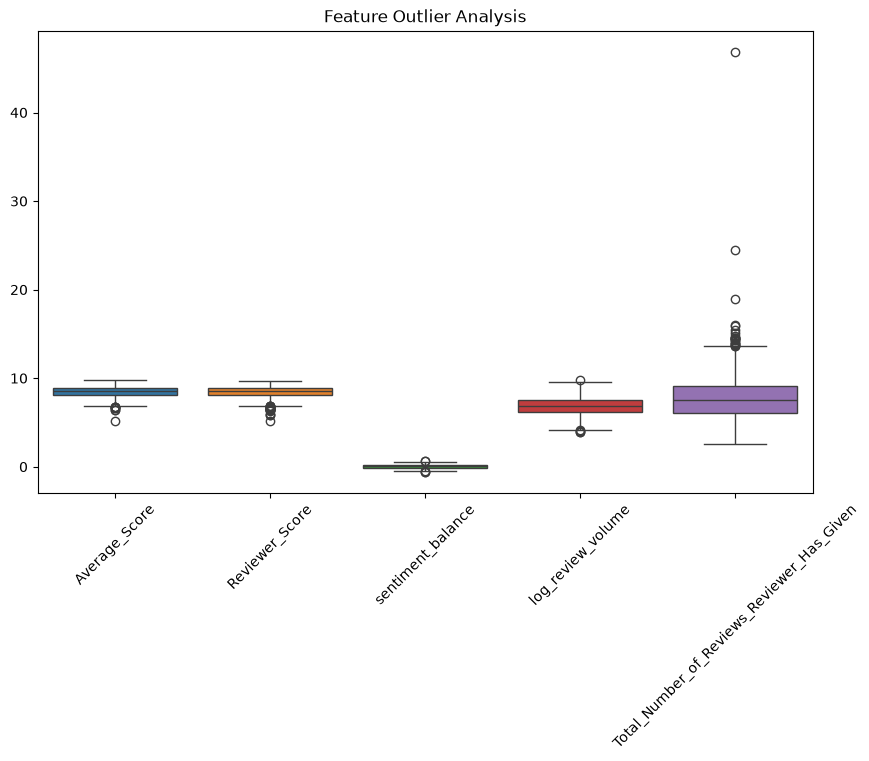

In [18]:
#PHASE 10 — Outlier Analysis

plt.figure(figsize=(10,6))
sns.boxplot(data=X)

plt.xticks(rotation=45)
plt.title("Feature Outlier Analysis")
plt.show()

In [19]:
#Check numerical statistics:
X.describe()

,Average_Score,Reviewer_Score,sentiment_balance,log_review_volume,Total_Number_of_Reviews_Reviewer_Has_Given
count,1492.000000,1492.000000,1492.000000,1492.000000,1492.000000
mean,8.467225,8.468132,0.034400,6.855912,7.825513
std,0.548412,0.622728,0.200036,0.986274,2.501348
min,5.200000,5.121538,-0.547588,3.931826,2.571429
25%,8.100000,8.093865,-0.105759,6.185178,6.095501
50%,8.500000,8.505886,0.025447,6.903245,7.515020
75%,8.900000,8.930305,0.168666,7.557212,9.123615
max,9.800000,9.725000,0.647309,9.774233,46.884615


In [20]:
#PHASE 11 — Feature Scaling

scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

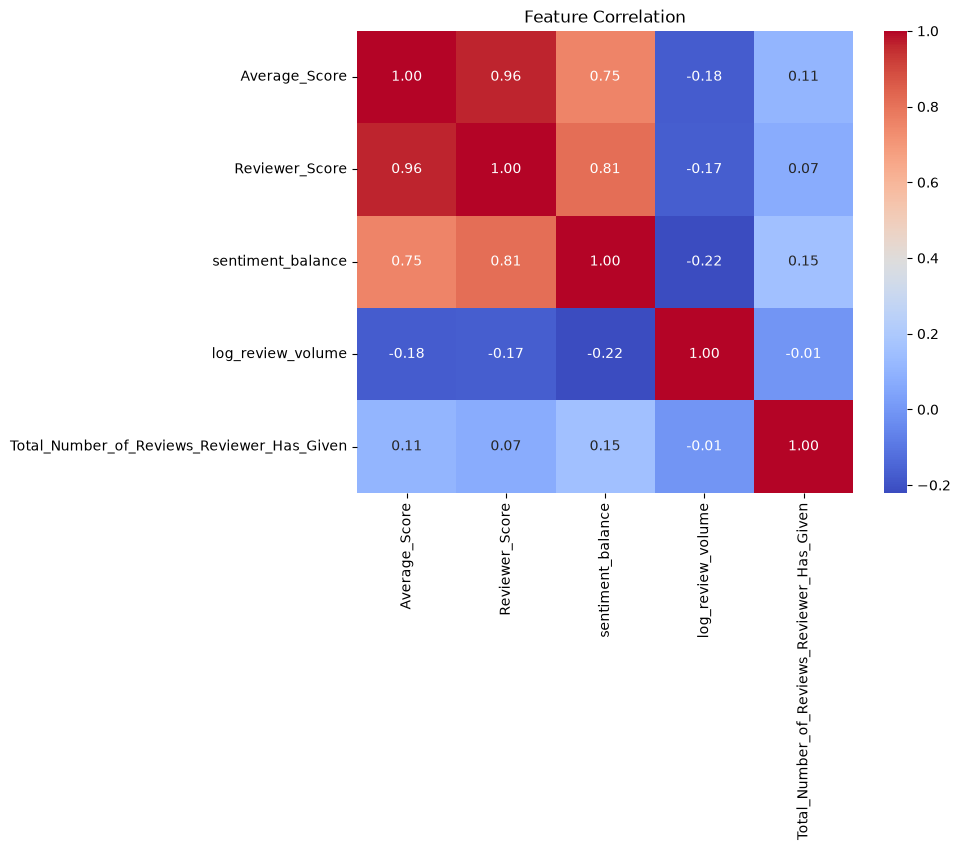

In [21]:
#PHASE 12 — Correlation / Redundancy Check  :-  Before clustering, check:

plt.figure(figsize=(8, 6))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation")
plt.show()

In [72]:
# PHASE 13 — Clustering Algorithm Experiments

# 13.1 — Import Algorithms and Metrics
from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN,
    SpectralClustering,
    MeanShift
)

from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

In [74]:
# 13.2 — K-Means

# We don't know the best K, so test 2–10.

kmeans_results = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    kmeans_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels)
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

print(kmeans_results_df)

    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.309732        1.210559         817.949601
1   3    0.236307        1.384795         642.045008
2   4    0.237415        1.321092         570.454032
3   5    0.235634        1.196737         528.505021
4   6    0.215880        1.240496         493.725026
5   7    0.206801        1.264370         460.305968
6   8    0.206465        1.126657         445.729800
7   9    0.206459        1.106789         429.180930
8  10    0.203073        1.176608         412.472634


In [75]:
#Select K using silhouette
best_kmeans_k = kmeans_results_df.loc[
    kmeans_results_df["silhouette"].idxmax(),
    "k"
]

best_kmeans_k = int(best_kmeans_k)

print("Best K-Means K:", best_kmeans_k)

Best K-Means K: 2


In [76]:
#Method 2 — Silhouette Score

silhouette_scores = []

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

   # Train the selected K-Means:

kmeans = KMeans(
    n_clusters=best_kmeans_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

In [77]:
#13.3 — Hierarchical Clustering
hierarchical_results = []

for k in range(2, 11):

    hierarchical = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward"
    )

    labels = hierarchical.fit_predict(X_scaled)

    hierarchical_results.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels)
    })

hierarchical_results_df = pd.DataFrame(
    hierarchical_results
)

print(hierarchical_results_df)

    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.274802        1.244293         669.384940
1   3    0.209407        1.453573         537.312233
2   4    0.218158        1.366933         484.102282
3   5    0.202349        1.323222         448.199580
4   6    0.169863        1.447900         420.877358
5   7    0.171189        1.256217         390.218523
6   8    0.162403        1.309056         370.996739
7   9    0.151056        1.314523         356.121227
8  10    0.148254        1.352241         341.075062


In [78]:
# Select the best K:

best_hierarchical_k = int(
    hierarchical_results_df.loc[
        hierarchical_results_df["silhouette"].idxmax(),
        "k"
    ]
)

print("Best Hierarchical K:", best_hierarchical_k)

Best Hierarchical K: 2


In [79]:
# Final labels:

hierarchical = AgglomerativeClustering(
    n_clusters=best_hierarchical_k,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(X_scaled)

In [81]:
# 13.4 — DBSCAN

# DBSCAN doesn't use K.

# We test different eps values.
dbscan_results = []

for eps in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:

    dbscan = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = dbscan.fit_predict(X_scaled)

    n_clusters = len(set(labels) - {-1})
    n_noise = np.sum(labels == -1)

    if n_clusters >= 2:

        mask = labels != -1

        silhouette = silhouette_score(
            X_scaled[mask],
            labels[mask]
        )

        davies = davies_bouldin_score(
            X_scaled[mask],
            labels[mask]
        )

        calinski = calinski_harabasz_score(
            X_scaled[mask],
            labels[mask]
        )

    else:

        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    dbscan_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_points": n_noise,
        "silhouette": silhouette,
        "davies_bouldin": davies,
        "calinski_harabasz": calinski
    })

dbscan_results_df = pd.DataFrame(dbscan_results)

print(dbscan_results_df)

   eps  clusters  noise_points  silhouette  davies_bouldin  calinski_harabasz
0  0.3         4          1468    0.660311        0.438865          83.426519
1  0.4        24          1115    0.095656        0.941457          57.353379
2  0.5         7           596   -0.203962        0.999172          10.791708
3  0.6         6           332   -0.177905        0.902202           9.043336
4  0.7         4           180   -0.000239        0.780648          16.676397
5  0.8         2           113    0.424163        0.489843          28.333360


In [83]:
# 13.5 — Gaussian Mixture Model
gmm_results = []

for k in range(2, 11):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    labels = gmm.fit_predict(X_scaled)

    gmm_results.append({
        "k": k,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        ),
        "bic": gmm.bic(X_scaled),
        "aic": gmm.aic(X_scaled)
    })

gmm_results_df = pd.DataFrame(gmm_results)

gmm_results_df



,k,silhouette,davies_bouldin,calinski_harabasz,bic,aic
0,2,0.179891,2.274403,211.604352,15037.571480,14819.948696
1,3,0.193803,1.884612,383.973901,14901.912628,14572.824515
2,4,0.134486,1.830183,184.427272,14664.953755,14224.400314
3,5,0.173240,1.453883,353.707951,14871.554617,14319.535847
4,6,0.095235,1.572850,235.999542,14828.077984,14164.593887
5,7,0.111448,1.725891,260.633591,14917.414328,14142.464902
6,8,0.079410,1.945860,185.526419,14907.977550,14021.562795
7,9,0.091518,1.663695,223.177866,14975.860269,13977.980186
8,10,0.067431,1.763821,207.021019,15055.098159,13945.752748


In [ ]:
# Select a suitable K.

# For this project, don't blindly select only by BIC/AIC or only silhouette. Inspect the table.

best_gmm_k = int(
    gmm_results_df.loc[
        gmm_results_df["silhouette"].idxmax(),
        "k"
    ]
)

print("Best GMM K based on silhouette:", best_gmm_k)

# Train:

gmm = GaussianMixture(
    n_components=best_gmm_k,
    random_state=42
)

gmm_labels = gmm.fit_predict(X_scaled)

In [84]:
# 13.6 — Mean Shift
from sklearn.cluster import MeanShift

mean_shift_results = []

bandwidth_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]

for bandwidth in bandwidth_values:

    mean_shift = MeanShift(
        bandwidth=bandwidth,
        bin_seeding=True
    )

    labels = mean_shift.fit_predict(X_scaled)

    n_clusters = len(np.unique(labels))

    if n_clusters >= 2:

        silhouette = silhouette_score(
            X_scaled,
            labels
        )

        davies = davies_bouldin_score(
            X_scaled,
            labels
        )

        calinski = calinski_harabasz_score(
            X_scaled,
            labels
        )

    else:

        silhouette = np.nan
        davies = np.nan
        calinski = np.nan

    cluster_counts = pd.Series(labels).value_counts()

    mean_shift_results.append({
        "bandwidth": bandwidth,
        "clusters": n_clusters,
        "smallest_cluster": cluster_counts.min(),
        "largest_cluster": cluster_counts.max(),
        "silhouette": silhouette,
        "davies_bouldin": davies,
        "calinski_harabasz": calinski
    })

mean_shift_results_df = pd.DataFrame(
    mean_shift_results
)

print(mean_shift_results_df)

   bandwidth  clusters  smallest_cluster  largest_cluster  silhouette  \
0       0.50       485                 1               18    0.146604   
1       0.75       145                 1              108    0.124007   
2       1.00        48                 1              458    0.055732   
3       1.25        19                 1              611    0.113826   
4       1.50         9                 1             1328    0.117824   
5       2.00         5                 1             1447    0.356999   

   davies_bouldin  calinski_harabasz  
0        0.687968          91.513862  
1        0.928304          98.235111  
2        1.022586          86.426892  
3        0.948567         124.346304  
4        0.952099          71.131609  
5        0.831857          65.474087  


In [85]:
# 13.7 — Spectral Clustering

# Your current notebook is missing this.

spectral_results = []

for k in range(2, 11):

    spectral = SpectralClustering(
        n_clusters=k,
        random_state=42,
        affinity="nearest_neighbors",
        assign_labels="kmeans"
    )

    labels = spectral.fit_predict(X_scaled)

    spectral_results.append({
        "k": k,
        "silhouette": silhouette_score(
            X_scaled,
            labels
        ),
        "davies_bouldin": davies_bouldin_score(
            X_scaled,
            labels
        ),
        "calinski_harabasz": calinski_harabasz_score(
            X_scaled,
            labels
        )
    })

spectral_results_df = pd.DataFrame(
    spectral_results
)

print(spectral_results_df)

    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.307340        1.217108         809.965317
1   3    0.236853        1.341935         623.364790
2   4    0.225910        1.300269         546.696261
3   5    0.224407        1.281447         486.222462
4   6    0.186168        1.249966         431.681399
5   7    0.192590        1.273264         432.046846
6   8    0.179964        1.272209         386.970871
7   9    0.166282        1.270650         372.512984
8  10    0.172296        1.342468         359.614471


In [89]:
# Select:

best_spectral_k = int(
    spectral_results_df.loc[
        spectral_results_df["silhouette"].idxmax(),
        "k"
    ]
)

print("Best Spectral K:", best_spectral_k)

# Train:

spectral = SpectralClustering(
    n_clusters=best_spectral_k,
    random_state=42,
    affinity="nearest_neighbors",
    assign_labels="kmeans"
)

spectral_labels = spectral.fit_predict(X_scaled)

Best Spectral K: 2


In [91]:
# PHASE 14 — Algorithm Evaluation & Comparison

# Now we compare the algorithms.

# 14.1 Evaluation Function
def evaluate_clustering(X, labels):

    unique_labels = set(labels)

    # Remove DBSCAN noise
    if -1 in unique_labels:

        mask = labels != -1

        X_eval = X[mask]
        labels_eval = labels[mask]

    else:

        X_eval = X
        labels_eval = labels

    n_clusters = len(
        np.unique(labels_eval)
    )

    if n_clusters < 2:

        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan,
            "Clusters": n_clusters,
            "Smallest_Cluster": np.nan,
            "Largest_Cluster": np.nan
        }

    cluster_counts = pd.Series(
        labels_eval
    ).value_counts()

    return {
        "Silhouette": silhouette_score(
            X_eval,
            labels_eval
        ),

        "Davies_Bouldin": davies_bouldin_score(
            X_eval,
            labels_eval
        ),

        "Calinski_Harabasz": calinski_harabasz_score(
            X_eval,
            labels_eval
        ),

        "Clusters": n_clusters,

        "Smallest_Cluster": cluster_counts.min(),

        "Largest_Cluster": cluster_counts.max()
    }


In [94]:
# 14.2 Compare All Algorithms

results = {}

results["K-Means"] = evaluate_clustering(
    X_scaled,
    kmeans_labels
)

results["Hierarchical"] = evaluate_clustering(
    X_scaled,
    hierarchical_labels
)

results["DBSCAN"] = evaluate_clustering(
    X_scaled,
    dbscan_labels
)

results["GMM"] = evaluate_clustering(
    X_scaled,
    gmm_labels
)

results["Mean Shift"] = evaluate_clustering(
    X_scaled,
    mean_shift_labels
)

results["Spectral"] = evaluate_clustering(
    X_scaled,
    spectral_labels
)


comparison_df = pd.DataFrame(
    results
).T

comparison_df

,Silhouette,Davies_Bouldin,Calinski_Harabasz,Clusters,Smallest_Cluster,Largest_Cluster
K-Means,0.309732,1.210559,817.949601,2.0,743.0,749.0
Hierarchical,0.274802,1.244293,669.384940,2.0,558.0,934.0
DBSCAN,-0.203962,0.999172,10.791708,7.0,2.0,869.0
GMM,0.134486,1.830183,184.427272,4.0,6.0,592.0
Mean Shift,0.340115,0.627469,46.873525,5.0,1.0,1468.0
Spectral,0.307340,1.217108,809.965317,2.0,723.0,769.0


In [95]:
# #14.3 — Understand the Metrics
# PHASE 15 — Select Final Algorithm

print(comparison_df)

              Silhouette  Davies_Bouldin  Calinski_Harabasz  Clusters  \
K-Means         0.309732        1.210559         817.949601       2.0   
Hierarchical    0.274802        1.244293         669.384940       2.0   
DBSCAN         -0.203962        0.999172          10.791708       7.0   
GMM             0.134486        1.830183         184.427272       4.0   
Mean Shift      0.340115        0.627469          46.873525       5.0   
Spectral        0.307340        1.217108         809.965317       2.0   

              Smallest_Cluster  Largest_Cluster  
K-Means                  743.0            749.0  
Hierarchical             558.0            934.0  
DBSCAN                     2.0            869.0  
GMM                        6.0            592.0  
Mean Shift                 1.0           1468.0  
Spectral                 723.0            769.0  


In [ ]:
# For our current notebook, the existing result is:

# Mean Shift:
# Silhouette       = 0.3401
# Davies-Bouldin   = 0.6275
# Calinski-Harabasz = 46.87
# Clusters         = 5

# But:

# 1468 / 1492 hotels → Cluster 0

# Therefore, the current default Mean Shift result should not yet be treated as the final model.
# After the bandwidth experiment, inspect:
mean_shift_results_df



,bandwidth,clusters,smallest_cluster,largest_cluster,silhouette,davies_bouldin,calinski_harabasz
0,0.50,485,1,18,0.146604,0.687968,91.513862
1,0.75,145,1,108,0.124007,0.928304,98.235111
2,1.00,48,1,458,0.055732,1.022586,86.426892
3,1.25,19,1,611,0.113826,0.948567,124.346304
4,1.50,9,1,1328,0.117824,0.952099,71.131609
5,2.00,5,1,1447,0.356999,0.831857,65.474087


In [98]:
# # PHASE 15 — Select Final Clustering Algorithm

# After comparing K-Means, Hierarchical Clustering, DBSCAN,
# GMM, Mean Shift, and Spectral Clustering, K-Means is selected
# as the final clustering algorithm.

# ## Selected Model

# Algorithm: K-Means
# Number of Clusters: 2

# ## Reason for Selection

# K-Means provides a strong combination of clustering quality
# and balanced cluster sizes.

# Silhouette Score: 0.3097
# Davies-Bouldin Score: 1.2106
# Calinski-Harabasz Score: 817.95

# Cluster sizes:

# Cluster 0: 743 hotels
# Cluster 1: 749 hotels

# Mean Shift achieved a higher Silhouette Score, but produced
# an extremely imbalanced clustering where 1468 out of 1492
# hotels belonged to one cluster.

# Therefore, K-Means with 2 clusters is selected as the final
# model because it provides a more balanced and practically
# interpretable segmentation of the hotels.
# PHASE 15 — Selected Final Algorithm

final_algorithm = "K-Means"
final_k = best_kmeans_k

print("Final Algorithm:", final_algorithm)
print("Number of Clusters:", final_k)

Final Algorithm: K-Means
Number of Clusters: 2


In [99]:
# PHASE 16 — Train Final K-Means Model

from sklearn.cluster import KMeans

final_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_model.fit_predict(X_scaled)

hotel_df["Cluster"] = final_labels

print("Final Algorithm: K-Means")
print("Number of Clusters:", hotel_df["Cluster"].nunique())

print("\nCluster Distribution:")
print(hotel_df["Cluster"].value_counts().sort_index())

Final Algorithm: K-Means
Number of Clusters: 2

Cluster Distribution:
Cluster
0    749
1    743
Name: count, dtype: int64


In [ ]:
#Checks :
print(
    hotel_df["Cluster"]
    .value_counts()
    .sort_index()
)

Cluster
0    749
1    743
Name: count, dtype: int64


In [101]:
#Checks number of clusters :- 
print(
    "Number of clusters:",
    hotel_df["Cluster"].nunique()
)

Number of clusters: 2


In [104]:
# PHASE 17 — Cluster Profiling

# Now we understand the clusters.

# 17.1 Cluster Profile
cluster_profile = (
    hotel_df
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_profile)

print("=====================================================")
# 17.2 Cluster Size
cluster_sizes = (
    hotel_df["Cluster"]
    .value_counts()
    .sort_index()
)

print(cluster_sizes)

         Average_Score  Reviewer_Score  sentiment_balance  log_review_volume  \
Cluster                                                                        
0             8.058344        7.995267          -0.111702           7.120436   
1             8.879408        8.944814           0.181682           6.589251   

         Total_Number_of_Reviews_Reviewer_Has_Given  
Cluster                                              
0                                          7.482714  
1                                          8.171079  
Cluster
0    749
1    743
Name: count, dtype: int64


In [106]:
# 17.3 Cluster Percentage
cluster_percentage = (
    hotel_df["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

print(cluster_percentage)

print("==================================================")
# 17.4 Complete Cluster Summary
cluster_summary = cluster_profile.copy()

cluster_summary["Hotel_Count"] = cluster_sizes

cluster_summary["Percentage"] = cluster_percentage

print(cluster_summary)

# This becomes your main cluster summary table.

Cluster
0    50.201072
1    49.798928
Name: proportion, dtype: float64
         Average_Score  Reviewer_Score  sentiment_balance  log_review_volume  \
Cluster                                                                        
0             8.058344        7.995267          -0.111702           7.120436   
1             8.879408        8.944814           0.181682           6.589251   

         Total_Number_of_Reviews_Reviewer_Has_Given  Hotel_Count  Percentage  
Cluster                                                                       
0                                          7.482714          749   50.201072  
1                                          8.171079          743   49.798928  


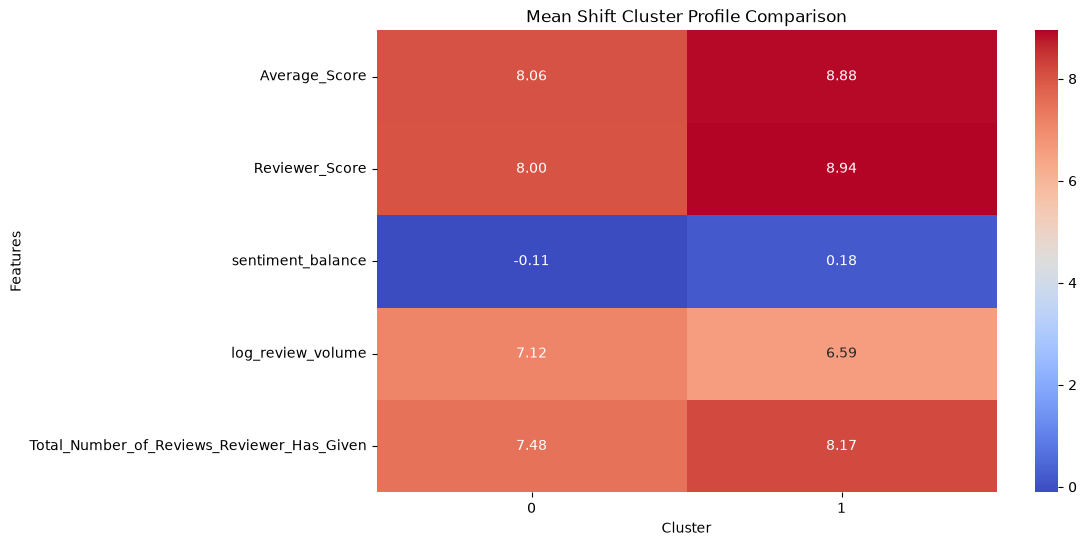

In [107]:
# PHASE 18 — Cluster Visualizations

# These are visualizations of the final clustering, not additional clustering algorithms.

# 18.1 Cluster Profile Heatmap

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_profile.T,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Mean Shift Cluster Profile Comparison")
plt.xlabel("Cluster")
plt.ylabel("Features")

plt.show()

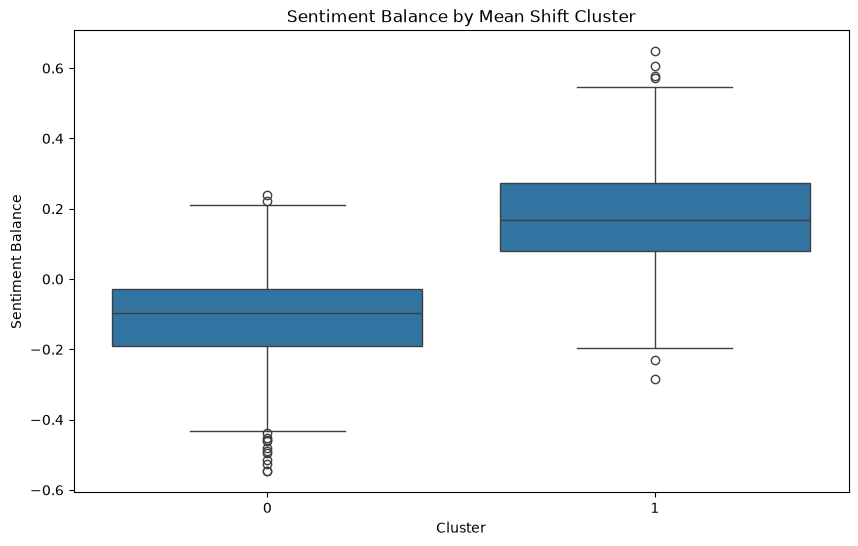

In [108]:
# 18.2 Sentiment Balance Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="sentiment_balance"
)

plt.title(
    "Sentiment Balance by Mean Shift Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Sentiment Balance")

plt.show()

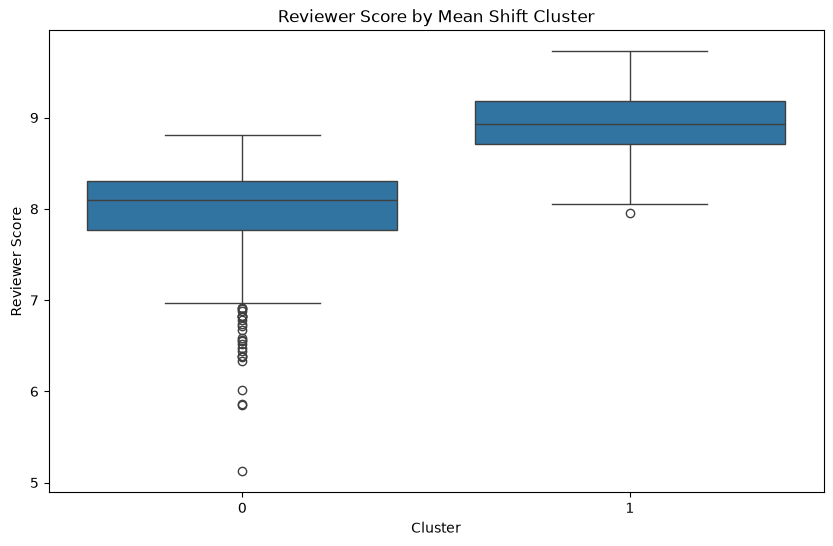

In [109]:
# 18.3 Reviewer Score Boxplot
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Reviewer_Score"
)

plt.title(
    "Reviewer Score by Mean Shift Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Reviewer Score")

plt.show()

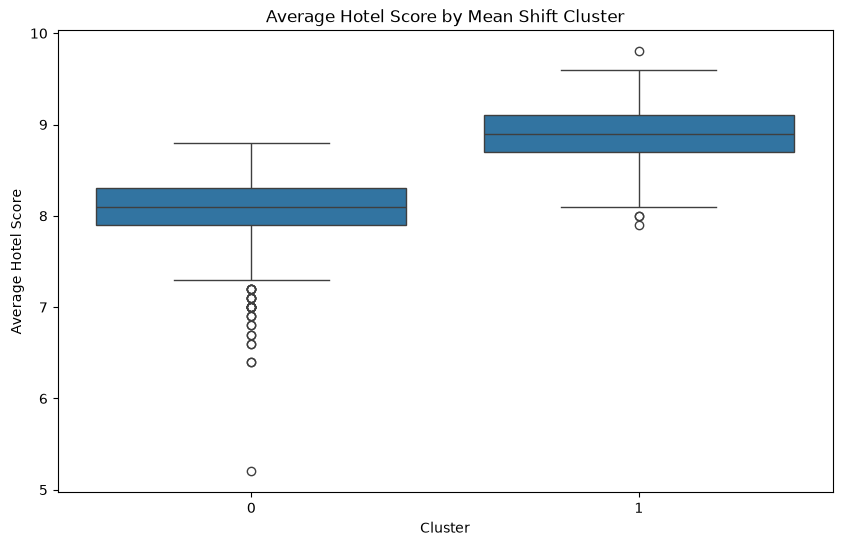

In [110]:
# 18.4 Average Hotel Score
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Average_Score"
)

plt.title(
    "Average Hotel Score by Mean Shift Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Average Hotel Score")

plt.show()

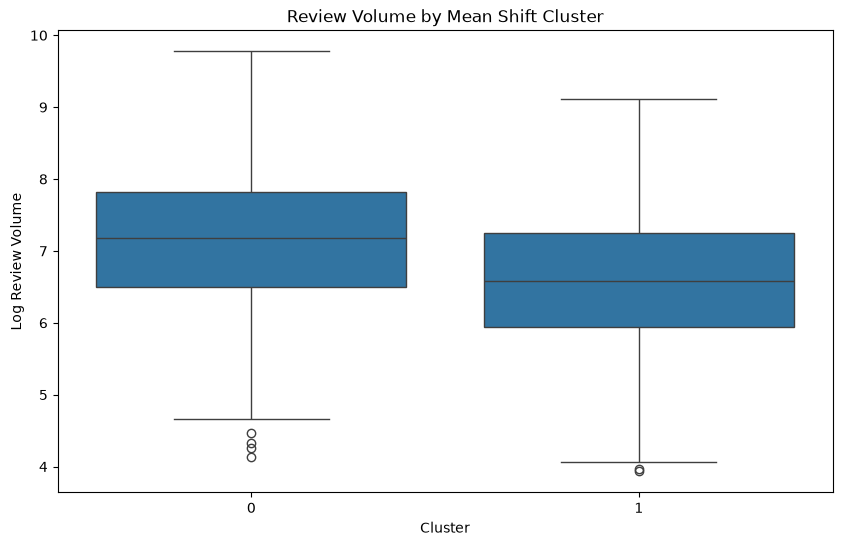

In [111]:
# 18.5 Review Volume
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="log_review_volume"
)

plt.title(
    "Review Volume by Mean Shift Cluster"
)

plt.xlabel("Cluster")
plt.ylabel("Log Review Volume")

plt.show()

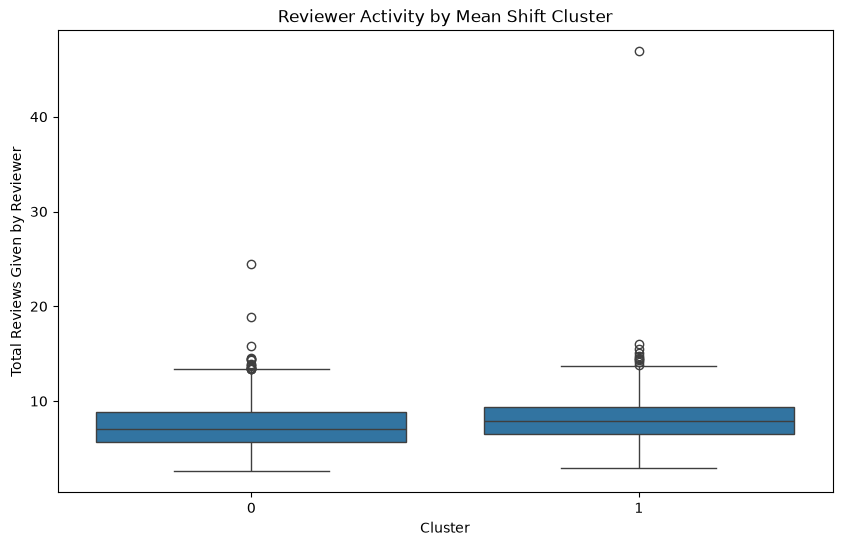

In [112]:
# 18.6 Reviewer Activity
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=hotel_df,
    x="Cluster",
    y="Total_Number_of_Reviews_Reviewer_Has_Given"
)

plt.title(
    "Reviewer Activity by Mean Shift Cluster"
)

plt.xlabel("Cluster")

plt.ylabel(
    "Total Reviews Given by Reviewer"
)

plt.show()

In [114]:
# 18.7 PCA Scatter Plot

# Remember:

# PCA is only for visualization here.

# It is not used to train the clustering model.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_scaled
)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = (
    hotel_df["Cluster"].values
)

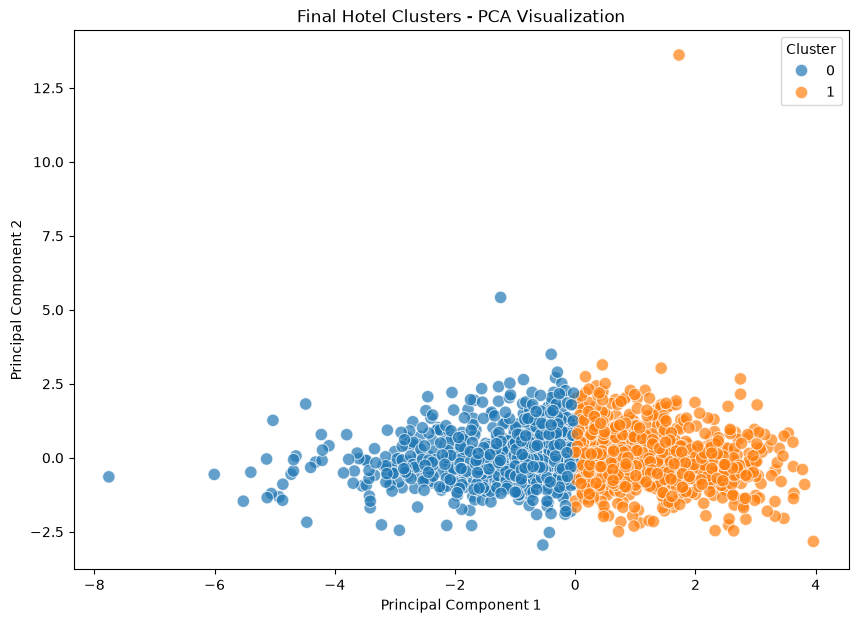

In [115]:
# Plot:

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    s=80,
    alpha=0.7
)

plt.title(
    "Final Hotel Clusters - PCA Visualization"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [116]:
# Explained variance:

print(
    "PC1 variance:",
    pca.explained_variance_ratio_[0]
)

print(
    "PC2 variance:",
    pca.explained_variance_ratio_[1]
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

PC1 variance: 0.5538887597840113
PC2 variance: 0.19903537500351348
Total explained variance: 0.7529241347875248


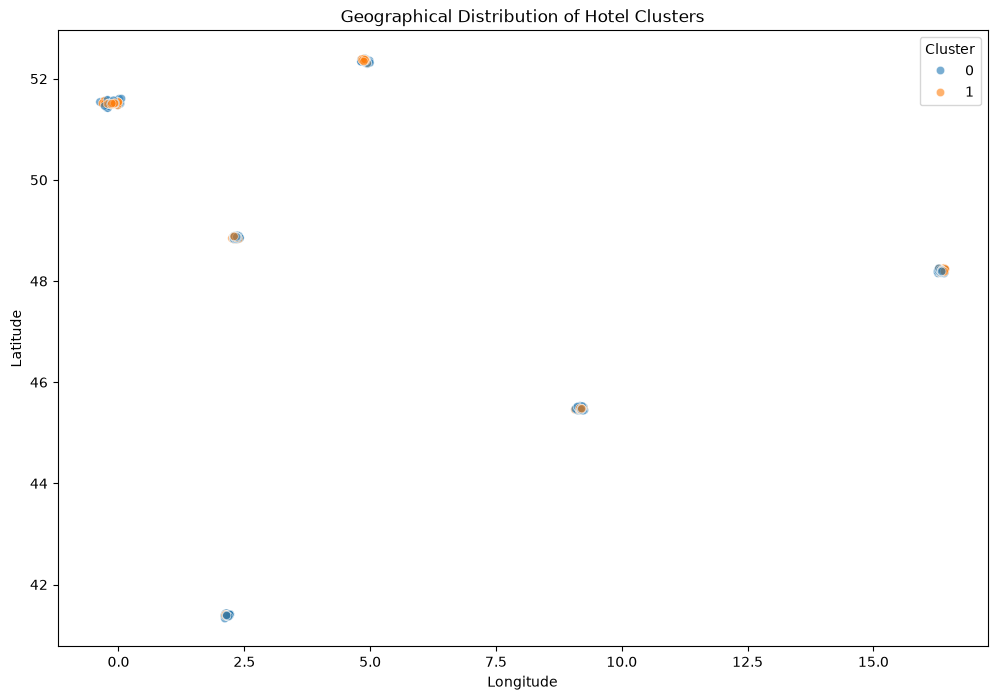

In [118]:
# PHASE 19 — Geographic Visualization

# This phase uses lat and lng.

# Remember:

# lat and lng were not used for clustering.

# They are only used here to understand the geographical distribution of the resulting clusters.

# First remove missing coordinates:
geo_df = hotel_df.dropna(
    subset=["lat", "lng"]
)


plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=geo_df,
    x="lng",
    y="lat",
    hue="Cluster",
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "Geographical Distribution of Hotel Clusters"
)

plt.show()

In [119]:
# PHASE 20 — Cluster Interpretation

# Now we answer:

# What does each cluster represent?

# 20.1 Compare Cluster Values
cluster_profile = (
    hotel_df
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_profile)

         Average_Score  Reviewer_Score  sentiment_balance  log_review_volume  \
Cluster                                                                        
0             8.058344        7.995267          -0.111702           7.120436   
1             8.879408        8.944814           0.181682           6.589251   

         Total_Number_of_Reviews_Reviewer_Has_Given  
Cluster                                              
0                                          7.482714  
1                                          8.171079  


In [120]:
# 20.2 Compare With Overall Average
overall_mean = hotel_df[features].mean()

cluster_difference = (
    cluster_profile - overall_mean
)

print(cluster_difference)

# This tells us whether a cluster is above or below the overall hotel average.

         Average_Score  Reviewer_Score  sentiment_balance  log_review_volume  \
Cluster                                                                        
0            -0.408881       -0.472864          -0.146103           0.264524   
1             0.412183        0.476683           0.147282          -0.266660   

         Total_Number_of_Reviews_Reviewer_Has_Given  
Cluster                                              
0                                         -0.342798  
1                                          0.345566  


In [121]:
# 20.3 Find Highest and Lowest Cluster
for feature in features:

    highest_cluster = (
        cluster_profile[feature]
        .idxmax()
    )

    lowest_cluster = (
        cluster_profile[feature]
        .idxmin()
    )

    print("\nFeature:", feature)

    print(
        "Highest Cluster:",
        highest_cluster
    )

    print(
        "Lowest Cluster:",
        lowest_cluster
    )


Feature: Average_Score
Highest Cluster: 1
Lowest Cluster: 0

Feature: Reviewer_Score
Highest Cluster: 1
Lowest Cluster: 0

Feature: sentiment_balance
Highest Cluster: 1
Lowest Cluster: 0

Feature: log_review_volume
Highest Cluster: 0
Lowest Cluster: 1

Feature: Total_Number_of_Reviews_Reviewer_Has_Given
Highest Cluster: 1
Lowest Cluster: 0


In [122]:
# 20.4 Print Every Cluster
for cluster in cluster_profile.index:

    print("\n" + "=" * 50)

    print(
        f"CLUSTER {cluster}"
    )

    print("=" * 50)

    for feature in features:

        value = cluster_profile.loc[
            cluster,
            feature
        ]

        print(
            f"{feature}: {value:.2f}"
        )

    print(
        "Hotel Count:",
        cluster_sizes.loc[cluster]
    )

    print(
        "Percentage:",
        f"{cluster_percentage.loc[cluster]:.2f}%"
    )


CLUSTER 0
Average_Score: 8.06
Reviewer_Score: 8.00
sentiment_balance: -0.11
log_review_volume: 7.12
Total_Number_of_Reviews_Reviewer_Has_Given: 7.48
Hotel Count: 749
Percentage: 50.20%

CLUSTER 1
Average_Score: 8.88
Reviewer_Score: 8.94
sentiment_balance: 0.18
log_review_volume: 6.59
Total_Number_of_Reviews_Reviewer_Has_Given: 8.17
Hotel Count: 743
Percentage: 49.80%


In [123]:
# PHASE 21 — Save Final Model & Results

# This is missing from your current notebook, so add it.

# 21.1 Save Final Clustering Model
import joblib

joblib.dump(
    final_model,
    "final_hotel_clustering_model.pkl"
)
# 21.2 Save Scaler


joblib.dump(
    scaler,
    "hotel_scaler.pkl"
)

['hotel_scaler.pkl']

In [124]:
# 21.3 Save PCA
joblib.dump(
    pca,
    "hotel_pca.pkl"
)

# PCA is saved because you may want the same visualization transformation later.

# 21.4 Save Clustered Dataset


hotel_df.to_csv(
    "hotel_clusters.csv",
    index=False
)
# 21.5 Save Feature List

# This is useful for deployment.

joblib.dump(
    features,
    "hotel_features.pkl"
)

['hotel_features.pkl']

In [125]:
# 21.6 Save Cluster Profile
cluster_profile.to_csv(
    "cluster_profile.csv"
)
# 21.7 Save Comparison Results
comparison_df.to_csv(
    "clustering_algorithm_comparison.csv"
)